# chap02_binary_codes.ipynb

**用途**：生成 `chap02_binary_lec.qmd` 中所需的全部图片，保存到 `./figs/` 目录。

图片列表：
- `fig01_scatter.png`：Size vs Leverage 散点图（按违约状态着色）
- `fig02_lpm_vs_logit.png`：LPM 与 Logit 拟合概率对比
- `fig03_link_functions.png`：三种链接函数对比
- `fig04_roc_confusion.png`：ROC 曲线 + 混淆矩阵
- `fig05_confounding.png`：混淆变量分析图

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.special import expit  # logistic function
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix
import statsmodels.api as sm
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('./figs', exist_ok=True)

# ── 全局绘图风格 ────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 150,
})
BLUE   = '#3B8BD4'
ORANGE = '#D85A30'
GRAY   = '#888780'

## 1. 生成模拟数据（DGP）

数据生成过程：
$$
\text{logit}(p_i) = -2.5 - 0.6\cdot\text{Size}_i + 4.0\cdot\text{Leverage}_i - 8.0\cdot\text{ROA}_i - 0.05\cdot\text{Age}_i + \text{行业效应} + \text{所有制效应}
$$

In [21]:
np.random.seed(42)
N = 1000

# 连续变量
size     = np.random.normal(8.0, 1.8, N)
lev      = np.clip(np.random.normal(0.45, 0.20, N), 0.05, 0.95)
roa      = np.clip(np.random.normal(0.05, 0.03, N), -0.10, 0.20)
age      = np.random.randint(1, 30, N).astype(float)

# 类别变量
industry  = np.random.choice(['manufacturing', 'real_estate', 'finance', 'tech'],
                              N, p=[0.40, 0.20, 0.20, 0.20])
ownership = np.random.choice(['state', 'private'], N, p=[0.40, 0.60])

# 行业和所有制固定效应
ind_fx  = {'manufacturing': 0.0, 'real_estate': 0.5, 'finance': -0.3, 'tech': 0.2}
own_fx  = {'state': -0.4, 'private': 0.2}

logit_v = (-2.5
           - 0.6 * (size - 8)
           + 4.0 * (lev  - 0.45)
           - 8.0 * (roa  - 0.05)
           - 0.05 * (age - 10)
           + np.array([ind_fx[i] for i in industry])
           + np.array([own_fx[o] for o in ownership]))

prob    = expit(logit_v)
default = (np.random.uniform(0, 1, N) < prob).astype(int)

df = pd.DataFrame({
    'default': default, 'size': size, 'leverage': lev,
    'roa': roa, 'age': age, 'industry': industry, 'ownership': ownership
})

print(f'样本量: {N},  违约率: {default.mean():.1%}')
print(df.head().round(3))

样本量: 1000,  违约率: 11.1%
   default    size  leverage    roa   age     industry ownership
0        0   8.894     0.730  0.030  22.0  real_estate   private
1        1   7.751     0.635  0.046  28.0  real_estate     state
2        0   9.166     0.462  0.026  26.0         tech   private
3        0  10.741     0.321  0.041   9.0  real_estate   private
4        0   7.579     0.590 -0.007   7.0      finance   private


## 2. fig01：散点图（Size vs Leverage，按违约状态着色）

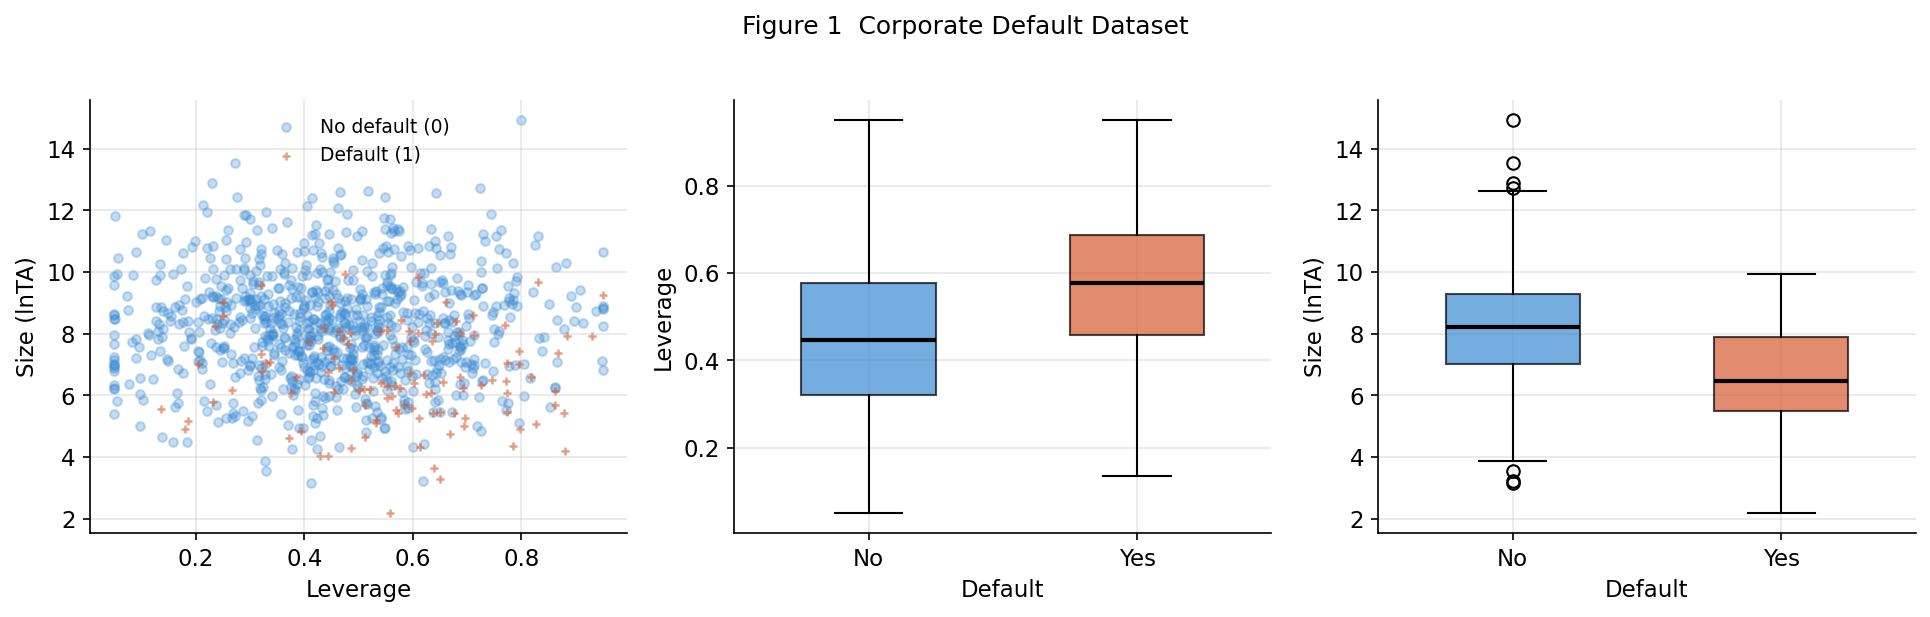

Saved: fig01_scatter.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

d0 = df[df.default==0]
d1 = df[df.default==1]

# ── 左图：散点图 ────────────────────────────────────────────
ax = axes[0]
ax.scatter(d0.leverage, d0['size'], alpha=0.3, s=18, color=BLUE,
           marker='o', label='No default (0)')
ax.scatter(d1.leverage, d1['size'], alpha=0.6, s=18, color=ORANGE,
           marker='+', linewidths=1.2, label='Default (1)')
ax.set_xlabel('Leverage')
ax.set_ylabel('Size (lnTA)')
ax.legend(frameon=False, fontsize=9)

# ── 中图：Leverage 的箱线图 ──────────────────────────────────
ax = axes[1]
bplot = ax.boxplot(
    [d0.leverage.values, d1.leverage.values],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)
bplot['boxes'][0].set_facecolor(BLUE)
bplot['boxes'][1].set_facecolor(ORANGE)
for b in bplot['boxes']: b.set_alpha(0.7)
ax.set_xticklabels(['No', 'Yes'])
ax.set_xlabel('Default')
ax.set_ylabel('Leverage')

# ── 右图：Size 的箱线图 ──────────────────────────────────────
ax = axes[2]
bplot2 = ax.boxplot(
    [d0['size'].values, d1['size'].values],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)
bplot2['boxes'][0].set_facecolor(BLUE)
bplot2['boxes'][1].set_facecolor(ORANGE)
for b in bplot2['boxes']: b.set_alpha(0.7)
ax.set_xticklabels(['No', 'Yes'])
ax.set_xlabel('Default')
ax.set_ylabel('Size (lnTA)')

plt.suptitle('Figure 1  Corporate Default Dataset', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('./figs/fig01_scatter.png', bbox_inches='tight')
plt.show()
print('Saved: fig01_scatter.png')

## 3. fig02：LPM vs Logit 拟合概率对比

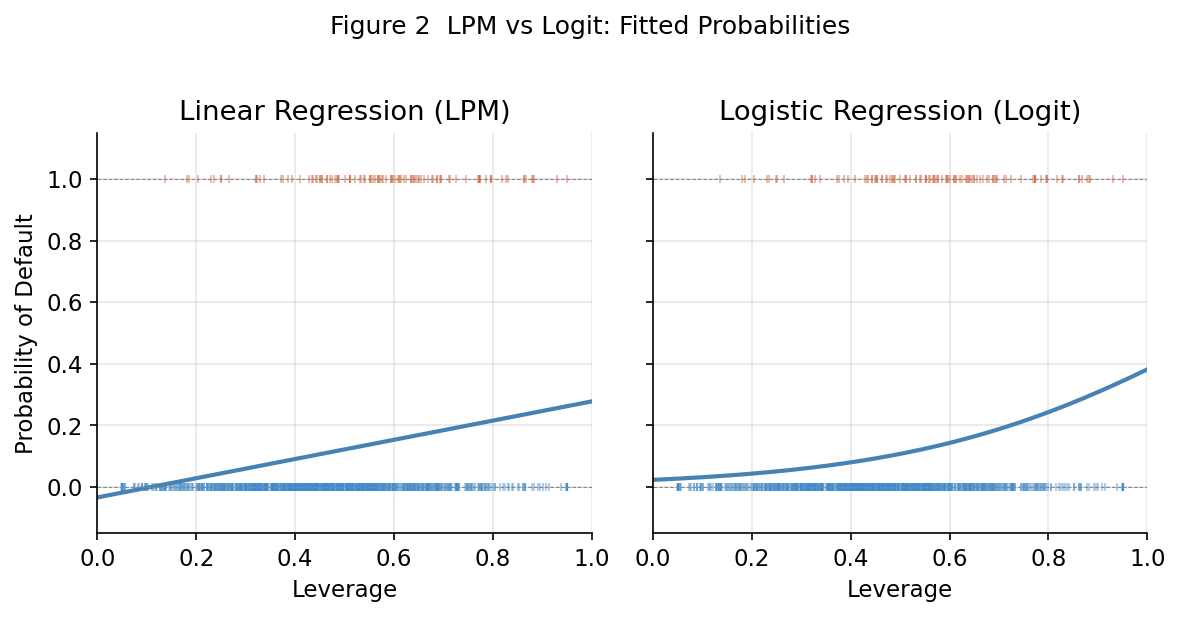

Saved: fig02_lpm_vs_logit.png


In [23]:
# 只用 Leverage 做单变量对比（更直观）
X1 = sm.add_constant(df[['leverage']])
y  = df['default'].values

# LPM
lpm   = sm.OLS(y, X1).fit()
# Logit
logit = sm.Logit(y, X1).fit(disp=0)

lev_grid = np.linspace(0.0, 1.0, 300)
X_grid   = sm.add_constant(pd.DataFrame({'leverage': lev_grid}))

prob_lpm   = lpm.predict(X_grid)
prob_logit = logit.predict(X_grid)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

for ax, probs, title in zip(
    axes,
    [prob_lpm, prob_logit],
    ['Linear Regression (LPM)', 'Logistic Regression (Logit)']
):
    # 观测值的 rug
    for yi, col in [(0, BLUE), (1, ORANGE)]:
        mask = y == yi
        ax.plot(df.leverage[mask], np.full(mask.sum(), yi),
                '|', color=col, alpha=0.4, markersize=4)
    # 拟合曲线
    ax.plot(lev_grid, probs, color='steelblue', lw=2)
    ax.axhline(0, color=GRAY, lw=0.5, ls='--')
    ax.axhline(1, color=GRAY, lw=0.5, ls='--')
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.15, 1.15)
    ax.set_xlabel('Leverage')
    ax.set_title(title)

axes[0].set_ylabel('Probability of Default')
plt.suptitle('Figure 2  LPM vs Logit: Fitted Probabilities', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('./figs/fig02_lpm_vs_logit.png', bbox_inches='tight')
plt.show()
print('Saved: fig02_lpm_vs_logit.png')

## 4. fig03：三种链接函数对比

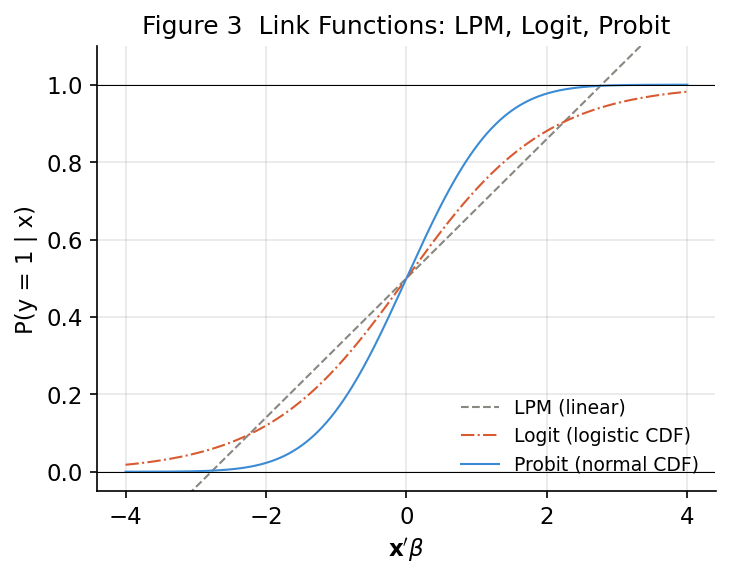

Saved: fig03_link_functions.png


In [24]:
u = np.linspace(-4, 4, 400)

lpm_fn    = 0.5 + 0.18 * u          # 示意性线性函数
logit_fn  = expit(u)
probit_fn = stats.norm.cdf(u)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(u, lpm_fn,    lw=1, ls='--',  color=GRAY,   label='LPM (linear)')
ax.plot(u, logit_fn,  lw=1, ls='-.',  color=ORANGE,  label='Logit (logistic CDF)')
ax.plot(u, probit_fn, lw=1, ls='-',   color=BLUE,   label='Probit (normal CDF)')
ax.axhline(0, color='black', lw=0.5)
ax.axhline(1, color='black', lw=0.5)
ax.set_xlabel("$\\mathbf{x}'\\beta$")
ax.set_ylabel('P(y = 1 | x)')
ax.set_ylim(-0.05, 1.10)
ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.title('Figure 3  Link Functions: LPM, Logit, Probit', fontsize=12)
plt.tight_layout()
plt.savefig('./figs/fig03_link_functions.png', bbox_inches='tight')
plt.show()
print('Saved: fig03_link_functions.png')

## 5. fig04：ROC 曲线 + 混淆矩阵

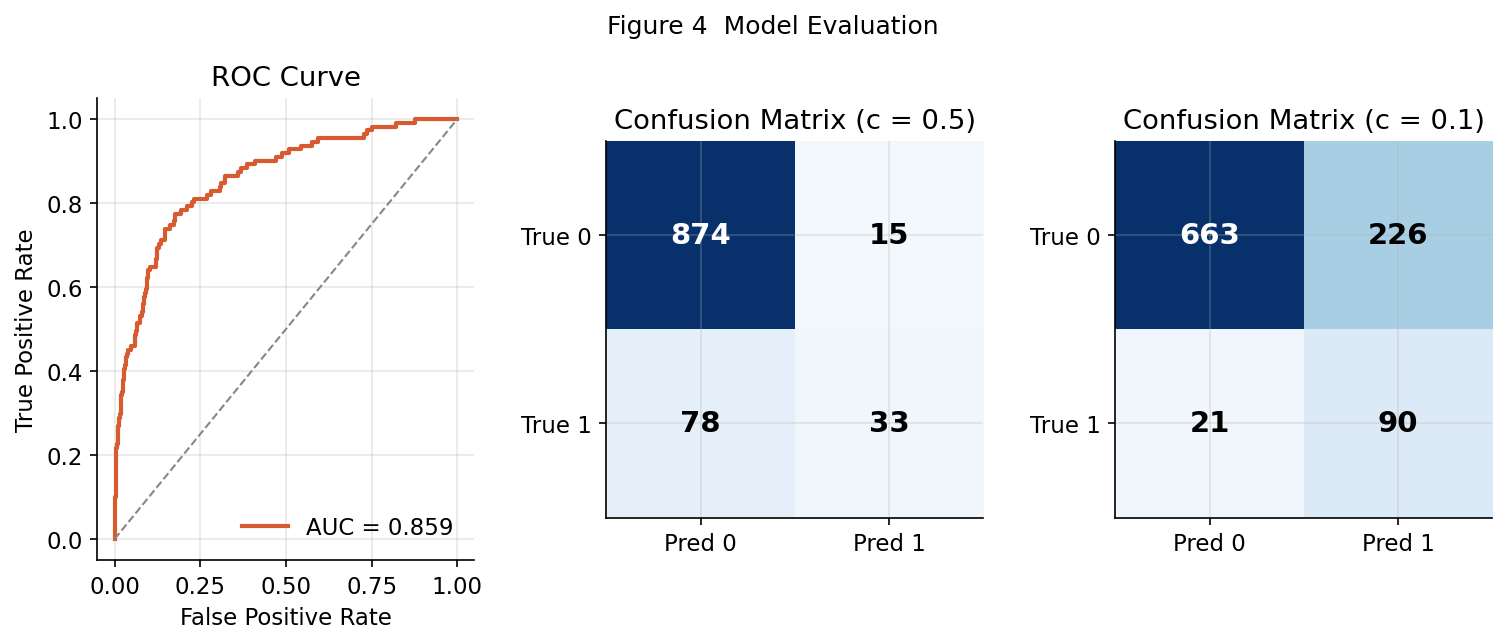

AUC = 0.859
Saved: fig04_roc_confusion.png


In [29]:
# 拟合多变量 Logit
df_tmp = df.copy()
df_tmp['industry'] = pd.Categorical(
    df_tmp['industry'],
    categories=['manufacturing', 'real_estate', 'finance', 'tech']
)
df_tmp['ownership'] = pd.Categorical(
    df_tmp['ownership'],
    categories=['private', 'state']
)

df_enc = pd.get_dummies(df_tmp, columns=['industry', 'ownership'], drop_first=True)
feat_cols = ['size', 'leverage', 'roa', 'age',
             'industry_real_estate', 'industry_finance', 'industry_tech',
             'ownership_state']
X_full = sm.add_constant(df_enc[feat_cols].astype(float))
logit_full = sm.Logit(df['default'].values, X_full).fit(disp=0)
prob_pred  = logit_full.predict(X_full)

# ROC
fpr, tpr, thresholds = roc_curve(y, prob_pred)
roc_auc = auc(fpr, tpr)

# 混淆矩阵（两个阈值）
cm_05 = confusion_matrix(y, (prob_pred > 0.5).astype(int))
cm_01 = confusion_matrix(y, (prob_pred > 0.1).astype(int))

fig = plt.figure(figsize=(12, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── ROC ──────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
ax0.plot(fpr, tpr, color=ORANGE, lw=2, label=f'AUC = {roc_auc:.3f}')
ax0.plot([0,1],[0,1], color=GRAY, ls='--', lw=1)
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('ROC Curve')
ax0.legend(frameon=False)

# ── 混淆矩阵（阈值 0.5）────────────────────────────────────
for ax, cm, thresh in [
    (fig.add_subplot(gs[1]), cm_05, 0.5),
    (fig.add_subplot(gs[2]), cm_01, 0.1)
]:
    im = ax.imshow(cm, cmap='Blues', vmin=0)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0','Pred 1'])
    ax.set_yticklabels(['True 0','True 1'])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[r,c] > cm.max()/2 else 'black')
    ax.set_title(f'Confusion Matrix (c = {thresh})')

plt.suptitle('Figure 4  Model Evaluation', y=1.02, fontsize=12)
plt.savefig('./figs/fig04_roc_confusion.png', bbox_inches='tight')
plt.show()
print(f'AUC = {roc_auc:.3f}')
print('Saved: fig04_roc_confusion.png')

## 6. fig05：混淆变量分析

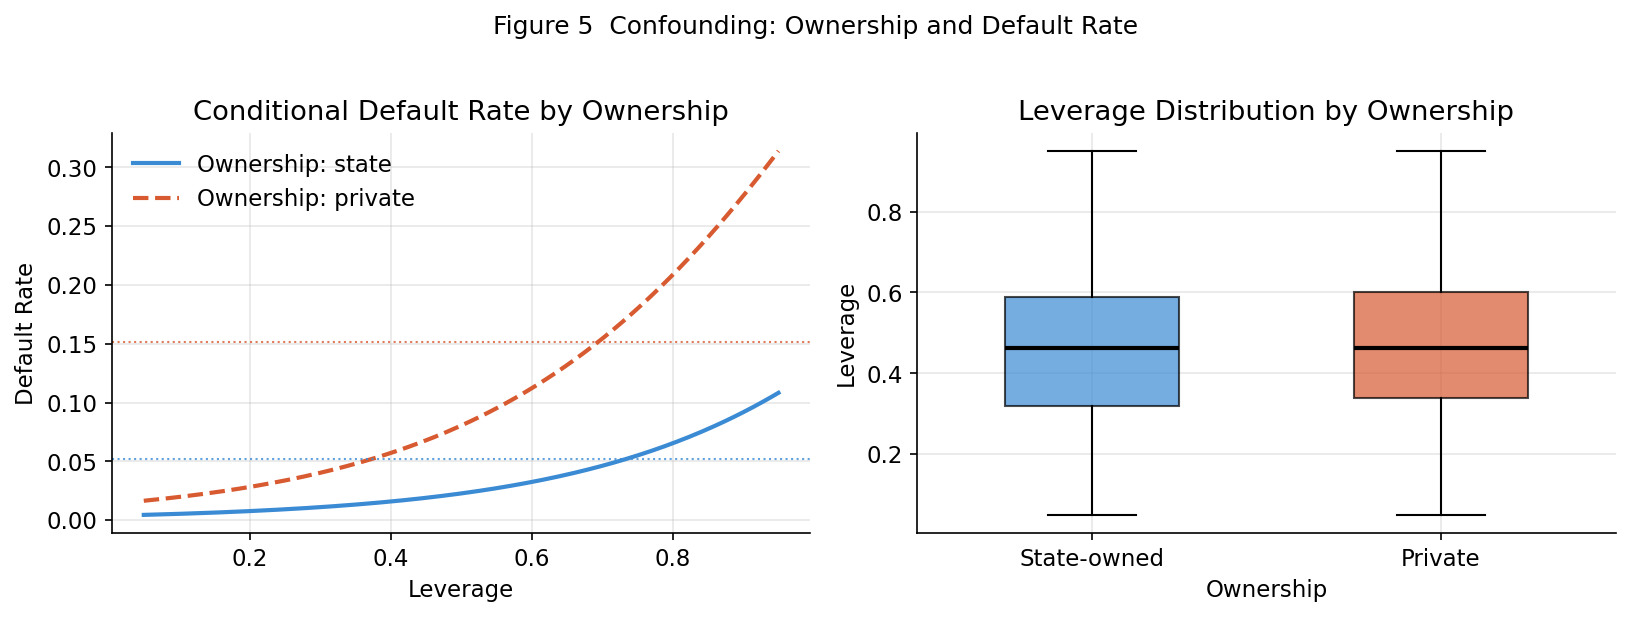

Saved: fig05_confounding.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── 左图：控制 Leverage 后的违约率曲线 ──────────────────────
ax = axes[0]
lev_grid = np.linspace(0.05, 0.95, 200)

for own, col, ls in [('state', BLUE, '-'), ('private', ORANGE, '--')]:
    # 其他变量取均值，只改 ownership 和 leverage
    xb_mean = (logit_full.params['const']
               + logit_full.params['size']    * df['size'].mean()
               + logit_full.params['roa']     * df['roa'].mean()
               + logit_full.params['age']     * df['age'].mean())
    own_coef = logit_full.params.get('ownership_state', 0) if own == 'state' else 0.0
    lev_coef = logit_full.params['leverage']

    prob_curve = expit(xb_mean + own_coef + lev_coef * lev_grid)
    ax.plot(lev_grid, prob_curve, color=col, ls=ls, lw=2,
            label=f'Ownership: {own}')

# 水平虚线：各自的平均违约率
for own, col in [('state', BLUE), ('private', ORANGE)]:
    mean_rate = df[df.ownership==own]['default'].mean()
    ax.axhline(mean_rate, color=col, lw=1, ls=':', alpha=0.8)

ax.set_xlabel('Leverage')
ax.set_ylabel('Default Rate')
ax.set_title('Conditional Default Rate by Ownership')
ax.legend(frameon=False)

# ── 右图：两类企业的 Leverage 分布 ──────────────────────────
ax = axes[1]
state_lev   = df[df.ownership=='state']['leverage']
private_lev = df[df.ownership=='private']['leverage']
bplot = ax.boxplot(
    [state_lev.values, private_lev.values],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)
bplot['boxes'][0].set_facecolor(BLUE);   bplot['boxes'][0].set_alpha(0.7)
bplot['boxes'][1].set_facecolor(ORANGE); bplot['boxes'][1].set_alpha(0.7)
ax.set_xticklabels(['State-owned', 'Private'])
ax.set_ylabel('Leverage')
ax.set_title('Leverage Distribution by Ownership')
ax.set_xlabel('Ownership')

plt.suptitle('Figure 5  Confounding: Ownership and Default Rate', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('./figs/fig05_confounding.png', bbox_inches='tight')
plt.show()
print('Saved: fig05_confounding.png')

## 7. 附：生成 lec.qmd 中用到的汇总统计

输出 Table 1（Logit 回归结果）和 Table 2（AME 对比）的数字。

In [27]:
print('=== Logit 完整模型结果 ===')
print(logit_full.summary2().tables[1].round(3))

print('\n=== AME (平均边际效应) ===')
margins = logit_full.get_margeff()
print(margins.summary())

=== Logit 完整模型结果 ===
                       Coef.  Std.Err.      z  P>|z|  [0.025  0.975]
const                  2.958     0.697  4.244  0.000   1.592   4.325
size                  -0.662     0.080 -8.319  0.000  -0.818  -0.506
leverage               3.680     0.640  5.746  0.000   2.425   4.935
roa                  -11.062     4.103 -2.696  0.007 -19.104  -3.020
age                   -0.090     0.016 -5.728  0.000  -0.120  -0.059
industry_real_estate   0.584     0.298  1.963  0.050   0.001   1.167
industry_finance      -0.199     0.348 -0.571  0.568  -0.881   0.483
industry_tech         -0.207     0.352 -0.587  0.557  -0.896   0.483
ownership_state       -1.327     0.281 -4.727  0.000  -1.878  -0.777

=== AME (平均边际效应) ===
        Logit Marginal Effects       
Dep. Variable:                      y
Method:                          dydx
At:                           overall
                          dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------

In [28]:
# LPM 系数作为对比
lpm_full = sm.OLS(y, X_full).fit(cov_type='HC3')
print('=== LPM 系数（等同于AME）===')
print(lpm_full.params[1:5].round(3))

=== LPM 系数（等同于AME）===
size       -0.050
leverage    0.290
roa        -0.929
age        -0.007
dtype: float64
